# 3D Blur/ Deblur

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import fftconvolve
from scipy.fft import fftn, ifftn
import scipy.io as sio
import warnings
import matplotlib.pyplot as plt
!pip install cvxpy
import cvxpy as cp
warnings.filterwarnings('ignore')

## Load MRI Data

In [26]:
mat = sio.loadmat('mri_data.mat')
vol_raw = np.squeeze(mat['D']).astype(np.float64)
X_true = vol_raw / vol_raw.max()
 
print(f"Loaded MRI volume: shape = {X_true.shape}, range = [{X_true.min():.2f}, {X_true.max():.2f}]")

Loaded MRI volume: shape = (128, 128, 27), range = [0.00, 1.00]


We have a 3D MRI volume stored as a discrete array $\mathbf{X} \in \mathbb{R}^{128 \times 128 \times 27}$. Each entry $X_{i,j,k}$ represents the intensity at spatial position $(i, j, k)$, where $i$ and $j$ index the rows and columns of a single brain slice, and $k$ indexes the slice number along the head-to-toe axis. There are 27 axial slices in total.

The raw data has integer pixel values in the range $[0, 88]$. We normalize for numerical stability by dividing by the maximum value:

$$X_{i,j,k} \leftarrow \frac{X_{i,j,k}}{\max_{i,j,k} X_{i,j,k}}$$

$\mathbf{X}$ denotes the true image that we want to recover.


## 3D Gaussian Point Spread Function (PSF)

In [27]:
def gaussian_kernel_3d(sigma, size=None):
    if size is None:
        size = int(2 * np.ceil(2 * sigma) + 1)
        
    if size % 2 == 0:
        size += 1
        
    half = size // 2
    ax = np.arange(-half, half + 1)
    z, y, x = np.meshgrid(ax, ax, ax, indexing='ij')
    
    kernel = np.exp(-(x**2 + y**2 + z**2) / (2 * sigma**2))
    kernel /= kernel.sum()
    
    return kernel

sigma_blur = 2.0
PSF = gaussian_kernel_3d(sigma_blur)

print(f"PSF: sigma = {sigma_blur}, kernel shape = {PSF.shape}, sum = {PSF.sum():.6f}")

PSF: sigma = 2.0, kernel shape = (9, 9, 9), sum = 1.000000


### The 1D Gaussian function

The starting point for the 3D Gaussian function is the one-dimensional Gaussian (normal) probability density function with mean $\mu = 0$ and standard deviation $\sigma$:

$$g(x) = \frac{1}{\sigma\sqrt{2\pi}} \exp\!\left(-\frac{x^2}{2\sigma^2}\right)$$

The parameter $\sigma$ controls the width of the bell curve. A larger $\sigma$ means a wider, flatter curve which gives more blur, while a smaller $\sigma$ means a narrow, peaked curve which means less blur.

Source: https://mathworld.wolfram.com/GaussianFunction.html


### Extending to 2D Gaussian Kernel

For a 2D image, blurring happens in both the horizontal and vertical directions. If the blur is isotropic (blur happens same in all directions) and separable (horizontal and vertical components does not depend on each other),then the 2D Gaussian PSF is the product of two 1D Gaussians:

$$G(x, y) = g(x) \cdot g(y) = \frac{1}{2\pi\sigma^2} e^{\!\left(-\frac{x^2 + y^2}{2\sigma^2}\right)}$$

Source: Hansen, Nagy & O'Leary, Chapter 3, in the special case where $s_1 = s_2 = \sigma$ and $\rho = 0$ (no rotation):

$$p_{ij} = \exp\!\left(-\frac{1}{2}\left(\frac{i - k}{s_1}\right)^2 - \frac{1}{2}\left(\frac{j - \ell}{s_2}\right)^2\right)$$

$$= \exp\!\left(-\frac{1}{2}\left(\frac{i - k}{\sigma}\right)^2 - \frac{1}{2}\left(\frac{j - \ell}{\sigma}\right)^2\right)$$
If we define new variables $x = i - k$and $y = j - \ell$, which measures the distance from the PSF center. This makes the equation to:
$$P(x,y) = \exp\!\left(-\frac{1}{2}\left(\frac{x}{\sigma}\right)^2 - \frac{1}{2}\left(\frac{y}{\sigma}\right)^2\right)$$
$$= \exp\!\left(-\frac{x^2 + y^2}{2\sigma^2}\right)$$

Note: The constant infront is not given in the book since it should be normalized and we are going to normalize with kernel /= kernel.sum().

### Extending to 3D Gaussian Kernel

For generalizing the N-dimension Gaussian Kernel we have:
$$G_{ND}(\vec{x};\sigma) = \frac{1}{(\sqrt{2\pi}\,\sigma)^N}\,e^{-\frac{\|\vec{x}\|^2}{2\sigma^2}}$$

The 3D isotropic Gaussian PSF is:
$$G(x, y, z) = \frac{1}{(\sqrt{2\pi}\sigma)^{2}} e^{\!\left(-\frac{x^2 + y^2 + z^2}{2\sigma^2}\right)}$$

Source: https://pages.stat.wisc.edu/~mchung/teaching/MIA/reading/diffusion.gaussian.kernel.pdf.pdf

Note: Same idea with 2D Gaussian Kernel that we do not need the constant term infront of the exponential since we are going to normalize it.


### Discretization and Normalization of 3D Gaussian Kernel

We evaluate this function on a discrete grid of integers centered at zero. The kernel size is $2\lceil 2\sigma \rceil + 1$ per axis, taken from MATLAB `imgaussfilt3`(https://www.mathworks.com/help/images/ref/imgaussfilt3.html) since we cannot and do not want the negliable small numbers.
With $\sigma = 2$, our PSF is a $9 \times 9 \times 9$ array.

Then we need to normalize the kernel so that all entries sum to 1:

$$G_{\text{normalized}}[i,j,k] = \frac{G[i,j,k]}{\sum_{i,j,k} G[i,j,k]}$$

This ensures that blurring preserves the total intensity of the image.

## 3D Blurring the Images

In [9]:
noise_level = 0.02
np.random.seed(42)

B = fftconvolve(X_true, PSF, mode='same')
noise = noise_level * np.random.randn(*X_true.shape)
B = B + noise

print(f"Blurred volume: noise σ_e = {noise_level}, range = [{B.min():.3f}, {B.max():.3f}]")

Blurred volume: noise σ_e = 0.02, range = [-0.089, 0.965]


### The linear blurring model

The fundamental image blurring model is:

$$\mathbf{b} = A\mathbf{x} + \mathbf{e}$$

where:

- $\mathbf{x} = \text{vec}(\mathbf{X}) \in \mathbb{R}^N$ is the true image reshaped into a column vector ($N = 128 \times 128 \times 27 = 442{,}368$),
- $A \in \mathbb{R}^{N \times N}$ is the blurring matrix,
- $\mathbf{e} \in \mathbb{R}^N$ is additive Gaussian noise with standard deviation $\sigma_e$,
- $\mathbf{b} \in \mathbb{R}^N$ is the observed blurred and noisy measurement.

Source: Hansen, Nagy & O'Leary, Chapter 1

### The Convolution Operation for 3D

The matrix $A$ encodes 3D convolution with the PSF. For each voxel $(i,j,k)$ in the output, the blurred value is a weighted average of surrounding voxels in the input:

$$B_{i, j, k} = \sum_{p} \sum_{q} \sum_{r} G_{p, q, r} \cdot X_{i - p, \; j - q, \; k - r}$$

where $G_{p,q,r}$ is the entry in the 3D Gaussian PSF at position $(p,q,r)$ which is the weight function. This ensures that the voxels closer to the center contribute more, while distant voxels contribute less. and $X_{i - p, \; j - q, \; k - r}$ is the image voxel at offset $(p,q,r)$ away from position $(i,j,k)$.

Source: Hansen, Nagy & O'Leary, Chapter 4

### The Fourier Transform for Convolution

Since doing 3D convolution is very expensive to calculate and store, which will be millions or billions of operations, we are going to use Fourier Transforms to perform these operations. We are going to use the function `fftconvolve` to do this in our code.

The blurring matrix $A$ with periodic boundary conditions is a BCCB (Block Circulant with Circulant Blocks) matrix which can be diagonalized by the Discrete Fourier Transform into:

$$A = F^* S F$$

where $F$ is the Discrete Fourier Transform matrix and $S$ is a diagonal matrix containing the spectral values $S = \text{diag}(s_1, s_2, \ldots, s_N)$. These spectral values are computed by applying the Fourier Transform to the PSF:

$$\mathbf{s} = F \, \mathbf{p}$$

where $\mathbf{p} = \text{vec}(P)$ is the PSF changed to a vector.

Because of this structure, the blurring operation $\mathbf{b} = A\mathbf{x}$ can be computed as:

$$\mathbf{b} = F^* S F \mathbf{x}$$

This final version of the equation can be solved in these three steps:

$$\hat{\mathbf{x}} = F\mathbf{x} \qquad \text{(FFT of the image)}$$

$$\hat{\mathbf{b}} = S\hat{\mathbf{x}} \qquad \text{(multiply by diagonal matrix)}$$

$$\mathbf{b} = F^*\hat{\mathbf{b}} \qquad \text{(inverse FFT to get the blurred image)}$$

For solving the second step no matrix inversion or matrix storage is needed since it is just computing $\hat{b}_i = s_i \cdot \hat{x}_i$ for each $i$  because $S$ is a diagonal matrix. The FFT and inverse FFT each take $O(N \log N)$ operations, and the multiplication takes $O(N)$ operations, so the total cost of using FFT is $O(N \log N)$ instead of $O(N^2)$ for a general matrix-vector product.

Source:Hansen, Nagy & O'Leary, Chapter 4 and 5

### Adding noise

After convolution, we add Gaussian noise:

$$B_{\text{observed}} = (G * X) + \mathbf{e}, \qquad e_{i,j,k} \sim \mathcal{N}(0, \sigma_e^2)$$

In the code we used $\sigma_e = 0.02$ with Normal distribution with randomness.

### Example Blur With Different Noise Values

In [17]:
noise_level_1 = 0.01
noise_level_2 = 0.02
noise_level_4 = 0.04
np.random.seed(42)

B_1 = fftconvolve(X_true, PSF, mode='same')
noise_1 = noise_level_1 * np.random.randn(*X_true.shape)
B_1 = B_1 + noise_1

B_2 = fftconvolve(X_true, PSF, mode='same')
noise_2 = noise_level_2 * np.random.randn(*X_true.shape)
B_2 = B_2 + noise_2

B_4 = fftconvolve(X_true, PSF, mode='same')
noise_4 = noise_level_4 * np.random.randn(*X_true.shape)
B_4 = B_4 + noise_4

print(f"Blurred volume: noise σ_e = {noise_level_1}, range = [{B_1.min():.3f}, {B_1.max():.3f}]")
print(f"Blurred volume: noise σ_e = {noise_level_2}, range = [{B_2.min():.3f}, {B_2.max():.3f}]")
print(f"Blurred volume: noise σ_e = {noise_level_4}, range = [{B_4.min():.3f}, {B_4.max():.3f}]")

Blurred volume: noise σ_e = 0.01, range = [-0.045, 0.946]
Blurred volume: noise σ_e = 0.02, range = [-0.097, 0.956]
Blurred volume: noise σ_e = 0.04, range = [-0.186, 1.013]


(np.float64(-0.5), np.float64(127.5), np.float64(127.5), np.float64(-0.5))

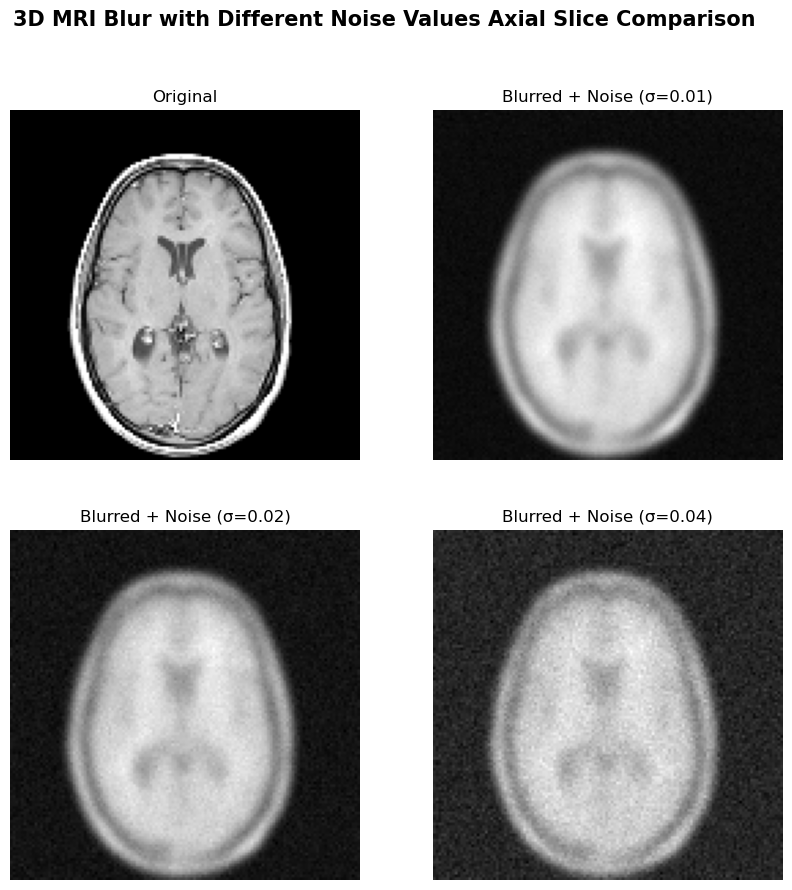

In [18]:
mid = X_true.shape[2] // 2
B_slice_1 = B_1[:, :, mid]
B_slice_2 = B_2[:, :, mid]
B_slice_4 = B_4[:, :, mid]

X_slice_true = X_true[:, :, mid]

fig1, axes1 = plt.subplots(2, 2, figsize=(10, 10))
fig1.suptitle('3D MRI Blur with Different Noise Values Axial Slice Comparison', fontsize=15, fontweight='bold')

axes1[0,0].imshow(X_slice_true, cmap='gray')
axes1[0,0].set_title('Original')
axes1[0,0].axis('off')

axes1[0,1].imshow(B_slice_1, cmap='gray')
axes1[0,1].set_title(f'Blurred + Noise (σ={noise_level_1})')
axes1[0,1].axis('off')

axes1[1,0].imshow(B_slice_2, cmap='gray')
axes1[1,0].set_title(f'Blurred + Noise (σ={noise_level_2})')
axes1[1,0].axis('off')

axes1[1,1].imshow(B_slice_4, cmap='gray')
axes1[1,1].set_title(f'Blurred + Noise (σ={noise_level_4})')
axes1[1,1].axis('off')

### Example Blur with Different Blur Widths (PSF)

In [23]:
#small
PSF_s = gaussian_kernel_3d(1.0)
#medium
PSF_m = gaussian_kernel_3d(2.0)
#large
PSF_l = gaussian_kernel_3d(4.0)

noise_level = 0.02
np.random.seed(42)

#small
B_s = fftconvolve(X_true, PSF_s, mode='same')
noise = noise_level * np.random.randn(*X_true.shape)
B_s = B_s + noise
#medium
B_m = fftconvolve(X_true, PSF_m, mode='same')
noise = noise_level * np.random.randn(*X_true.shape)
B_m = B_m + noise
#large
B_l = fftconvolve(X_true, PSF_l, mode='same')
noise = noise_level * np.random.randn(*X_true.shape)
B_l = B_l + noise

print(f"Blurred volume: noise σ_blur = 1.0, range = [{B_s.min():.3f}, {B_s.max():.3f}]")
print(f"Blurred volume: noise σ_blur = 2.0, range = [{B_m.min():.3f}, {B_m.max():.3f}]")
print(f"Blurred volume: noise σ_blur = 4.0, range = [{B_l.min():.3f}, {B_l.max():.3f}]")

Blurred volume: noise σ_blur = 1.0, range = [-0.089, 1.055]
Blurred volume: noise σ_blur = 2.0, range = [-0.097, 0.956]
Blurred volume: noise σ_blur = 4.0, range = [-0.093, 0.803]


(np.float64(-0.5), np.float64(127.5), np.float64(127.5), np.float64(-0.5))

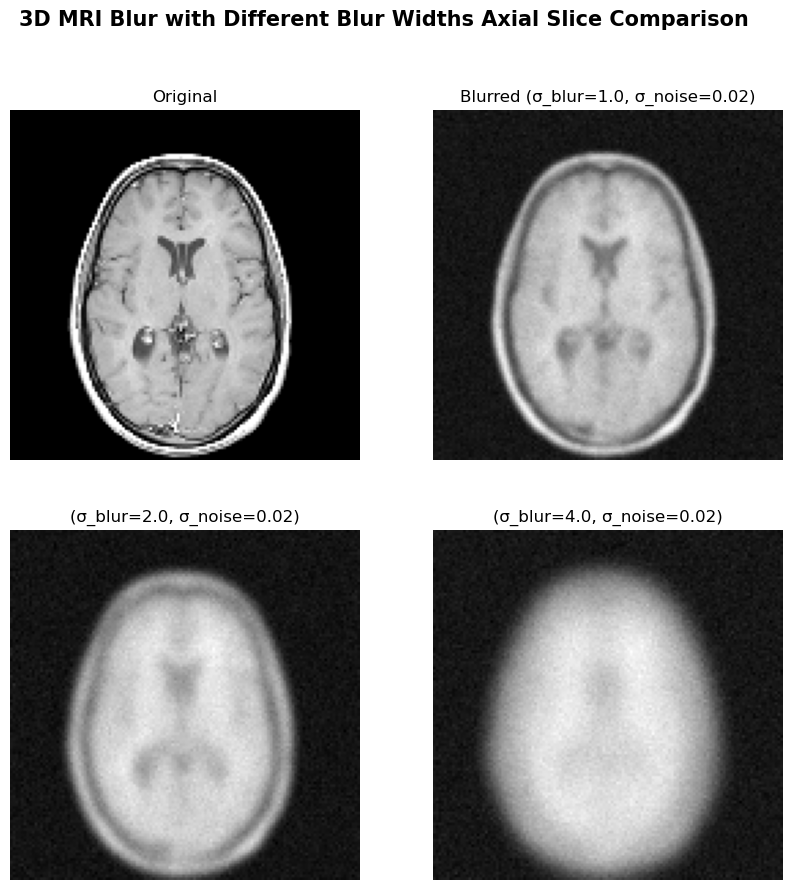

In [25]:
mid = X_true.shape[2] // 2
B_slice_s = B_s[:, :, mid]
B_slice_m = B_m[:, :, mid]
B_slice_l = B_l[:, :, mid]

X_slice_true = X_true[:, :, mid]

fig1, axes1 = plt.subplots(2, 2, figsize=(10, 10))
fig1.suptitle('3D MRI Blur with Different Blur Widths Axial Slice Comparison', fontsize=15, fontweight='bold')

axes1[0,0].imshow(X_slice_true, cmap='gray')
axes1[0,0].set_title('Original')
axes1[0,0].axis('off')

axes1[0,1].imshow(B_slice_s, cmap='gray')
axes1[0,1].set_title(f'Blurred (σ_blur={1.0}, σ_noise={noise_level})')
axes1[0,1].axis('off')

axes1[1,0].imshow(B_slice_m, cmap='gray')
axes1[1,0].set_title(f'(σ_blur={2.0}, σ_noise={noise_level})')
axes1[1,0].axis('off')

axes1[1,1].imshow(B_slice_l, cmap='gray')
axes1[1,1].set_title(f'(σ_blur={4.0}, σ_noise={noise_level})')
axes1[1,1].axis('off')